In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import shutil

base_path = "/content/drive/MyDrive/Colab Notebooks/ham_dataset1"

metadata_path = os.path.join(base_path,"HAM10000_metadata.csv")
image_folder1 = os.path.join(base_path,"HAM10000_images_part_1")
image_folder2 = os.path.join(base_path,"HAM10000_images_part_2")

output_folder = os.path.join(base_path,"dataset")

df = pd.read_csv(metadata_path)

# create folders
for disease in df['dx'].unique():
    os.makedirs(os.path.join(output_folder,disease),exist_ok=True)

# move images
for _,row in df.iterrows():

    image_name = row['image_id'] + ".jpg"
    label = row['dx']

    path1 = os.path.join(image_folder1,image_name)
    path2 = os.path.join(image_folder2,image_name)

    if os.path.exists(path1):
        source = path1
    elif os.path.exists(path2):
        source = path2
    else:
        continue

    destination = os.path.join(output_folder,label,image_name)

    shutil.move(source,destination)

print("Dataset separated successfully")

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/ham_dataset1/"

dataset  HAM10000_images_part_1  HAM10000_images_part_2  HAM10000_metadata.csv


In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/ham_dataset1/dataset"

akiec  bcc  bkl  df  mel  nv  vasc


In [ ]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/ham_dataset1/dataset" "/content/"

In [ ]:
!ls /content/

content  dataset  drive  ham_dataset.zip  sample_data


In [ ]:
!ls /content/dataset

akiec  bcc  bkl  df  mel  nv  vasc


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# DATA PREPARATION
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=preprocess_input,
    validation_split=0.2
)


train_gen = train_datagen.flow_from_directory(
    '/content/dataset',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    '/content/dataset',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# MODEL ARCHITECTURE
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Initially frozen

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(7, activation='softmax')
])

# INITIAL TRAINING
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
print("Starting Warm-up Training...")
model.fit(train_gen, validation_data=val_gen, epochs=5)





Found 8015 images belonging to 7 classes.
Found 2000 images belonging to 7 classes.
Starting Warm-up Training...
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 256s 935ms/step - accuracy: 0.5904 - loss: 1.3187 - val_accuracy: 0.6955 - val_loss: 0.8613
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 710ms/step - accuracy: 0.6951 - loss: 0.9146 - val_accuracy: 0.7500 - val_loss: 0.7355
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 700ms/step - accuracy: 0.7072 - loss: 0.8537 - val_accuracy: 0.7555 - val_loss: 0.6787
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 175s 696ms/step - accuracy: 0.7209 - loss: 0.8025 - val_accuracy: 0.7620 - val_loss: 0.6775
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 174s 694ms/step - accuracy: 0.7300 - loss: 0.7576 - val_accuracy: 0.7630 - val_loss: 0.6588


In [ ]:
# FINE-TUNING
print("\nStarting Fine-Tuning...")

# Unfreeze last 80 layers
base_model.trainable = True
for layer in base_model.layers[:-80]:
    layer.trainable = False

for layer in base_model.layers[-80:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint('best_skin_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

# Full Training
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[checkpoint, reduce_lr, early_stop]
)


Starting Fine-Tuning...
Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.7336 - loss: 0.7460
Epoch 1: val_accuracy improved from None to 0.78350, saving model to best_skin_model.h5



Epoch 1: finished saving model to best_skin_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 246s 851ms/step - accuracy: 0.7496 - loss: 0.7112 - val_accuracy: 0.7835 - val_loss: 0.6029 - learning_rate: 1.0000e-04
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.7906 - loss: 0.5769
Epoch 2: val_accuracy did not improve from 0.78350
251/251 ━━━━━━━━━━━━━━━━━━━━ 175s 697ms/step - accuracy: 0.7934 - loss: 0.5794 - val_accuracy: 0.7755 - val_loss: 0.6737 - learning_rate: 1.0000e-04
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.8009 - loss: 0.5480
Epoch 3: val_accuracy improved from 0.78350 to 0.80650, saving model to best_skin_model.h5



Epoch 3: finished saving model to best_skin_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 708ms/step - accuracy: 0.8045 - loss: 0.5444 - val_accuracy: 0.8065 - val_loss: 0.5740 - learning_rate: 1.0000e-04
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.8265 - loss: 0.4812
Epoch 4: val_accuracy improved from 0.80650 to 0.81700, saving model to best_skin_model.h5



Epoch 4: finished saving model to best_skin_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 706ms/step - accuracy: 0.8230 - loss: 0.4845 - val_accuracy: 0.8170 - val_loss: 0.5056 - learning_rate: 1.0000e-04
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.8390 - loss: 0.4443
Epoch 5: val_accuracy did not improve from 0.81700
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 700ms/step - accuracy: 0.8384 - loss: 0.4560 - val_accuracy: 0.8090 - val_loss: 0.5784 - learning_rate: 1.0000e-04
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.8452 - loss: 0.4179
Epoch 6: val_accuracy improved from 0.81700 to 0.83900, saving model to best_skin_model.h5



Epoch 6: finished saving model to best_skin_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 709ms/step - accuracy: 0.8440 - loss: 0.4198 - val_accuracy: 0.8390 - val_loss: 0.4578 - learning_rate: 1.0000e-04
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.8653 - loss: 0.3775
Epoch 7: val_accuracy did not improve from 0.83900
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 702ms/step - accuracy: 0.8606 - loss: 0.3883 - val_accuracy: 0.8260 - val_loss: 0.5019 - learning_rate: 1.0000e-04
Epoch 8/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.8631 - loss: 0.3733
Epoch 8: val_accuracy improved from 0.83900 to 0.84700, saving model to best_skin_model.h5


...


Epoch 11: finished saving model to best_skin_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 177s 705ms/step - accuracy: 0.9022 - loss: 0.2703 - val_accuracy: 0.8515 - val_loss: 0.4388 - learning_rate: 2.0000e-05
Epoch 12/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9103 - loss: 0.2497
Epoch 12: val_accuracy did not improve from 0.85150
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 709ms/step - accuracy: 0.9053 - loss: 0.2581 - val_accuracy: 0.8495 - val_loss: 0.4294 - learning_rate: 2.0000e-05
Epoch 13/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.9131 - loss: 0.2430
Epoch 13: val_accuracy improved from 0.85150 to 0.85550, saving model to best_skin_model.h5



Epoch 13: finished saving model to best_skin_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 707ms/step - accuracy: 0.9129 - loss: 0.2418 - val_accuracy: 0.8555 - val_loss: 0.4204 - learning_rate: 2.0000e-05
Epoch 14/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.9214 - loss: 0.2278
Epoch 14: val_accuracy did not improve from 0.85550
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 700ms/step - accuracy: 0.9158 - loss: 0.2408 - val_accuracy: 0.8545 - val_loss: 0.4150 - learning_rate: 2.0000e-05
Epoch 15/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.9117 - loss: 0.2434
Epoch 15: val_accuracy improved from 0.85550 to 0.86150, saving model to best_skin_model.h5



Epoch 15: finished saving model to best_skin_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 177s 707ms/step - accuracy: 0.9143 - loss: 0.2351 - val_accuracy: 0.8615 - val_loss: 0.4101 - learning_rate: 2.0000e-05
Epoch 16/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.9197 - loss: 0.2251
Epoch 16: val_accuracy did not improve from 0.86150
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 700ms/step - accuracy: 0.9183 - loss: 0.2327 - val_accuracy: 0.8535 - val_loss: 0.4322 - learning_rate: 2.0000e-05
Epoch 17/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.9144 - loss: 0.2294
Epoch 17: val_accuracy did not improve from 0.86150
251/251 ━━━━━━━━━━━━━━━━━━━━ 175s 696ms/step - accuracy: 0.9173 - loss: 0.2244 - val_accuracy: 0.8515 - val_loss: 0.4014 - learning_rate: 2.0000e-05
Epoch 18/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.9292 - loss: 0.1995
Epoch 18: val_accuracy did not improve from 0.86150
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 701ms/step - accuracy: 0.9250 - loss: 0.2


Epoch 19: finished saving model to best_skin_model.h5

Epoch 19: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 700ms/step - accuracy: 0.9219 - loss: 0.2169 - val_accuracy: 0.8625 - val_loss: 0.4109 - learning_rate: 2.0000e-05
Epoch 20/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.9270 - loss: 0.2056
Epoch 20: val_accuracy did not improve from 0.86250
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 708ms/step - accuracy: 0.9284 - loss: 0.2051 - val_accuracy: 0.8560 - val_loss: 0.4191 - learning_rate: 4.0000e-06
Epoch 21/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.9284 - loss: 0.1998
Epoch 21: val_accuracy did not improve from 0.86250

Epoch 21: ReduceLROnPlateau reducing learning rate to 7.999999979801942e-07.
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 700ms/step - accuracy: 0.9273 - loss: 0.1978 - val_accuracy: 0.8580 - val_loss: 0.4176 - learning_rate: 4.0000e-06
Epoch 22/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - acc


Epoch 22: finished saving model to best_skin_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 700ms/step - accuracy: 0.9331 - loss: 0.1930 - val_accuracy: 0.8645 - val_loss: 0.4185 - learning_rate: 8.0000e-07
Epoch 23/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9259 - loss: 0.2045
Epoch 23: val_accuracy did not improve from 0.86450

Epoch 23: ReduceLROnPlateau reducing learning rate to 1.600000018697756e-07.
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 711ms/step - accuracy: 0.9278 - loss: 0.2003 - val_accuracy: 0.8605 - val_loss: 0.4211 - learning_rate: 8.0000e-07
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 17.


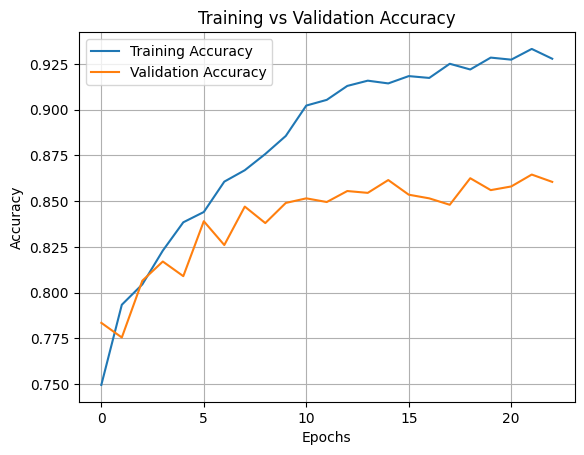

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# CLASS WEIGHTS

labels = train_gen.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

# UNFREEZE MORE LAYERS

base_model.trainable = True

for layer in base_model.layers[:-120]:
    layer.trainable = False

for layer in base_model.layers[-120:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# LOW LR

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# TRAINING

print("\n Starting final Training...")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    class_weight=class_weights,
    callbacks=[checkpoint, reduce_lr, early_stop]
)


 Starting final Training...
Epoch 1/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.9265 - loss: 0.2813
Epoch 1: val_accuracy improved from None to 0.85450, saving model to best_skin_model_final.h5



Epoch 1: finished saving model to best_skin_model_final.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 237s 823ms/step - accuracy: 0.9253 - loss: 0.2819 - val_accuracy: 0.8545 - val_loss: 0.4224 - learning_rate: 1.0000e-05
Epoch 2/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.9152 - loss: 0.2614
Epoch 2: val_accuracy did not improve from 0.85450
251/251 ━━━━━━━━━━━━━━━━━━━━ 177s 703ms/step - accuracy: 0.9143 - loss: 0.2737 - val_accuracy: 0.8500 - val_loss: 0.4193 - learning_rate: 1.0000e-05
Epoch 3/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.9164 - loss: 0.2512
Epoch 3: val_accuracy improved from 0.85450 to 0.85600, saving model to best_skin_model_final.h5



Epoch 3: finished saving model to best_skin_model_final.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 701ms/step - accuracy: 0.9145 - loss: 0.2645 - val_accuracy: 0.8560 - val_loss: 0.4129 - learning_rate: 1.0000e-05
Epoch 4/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.9129 - loss: 0.2533
Epoch 4: val_accuracy did not improve from 0.85600
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 709ms/step - accuracy: 0.9123 - loss: 0.2526 - val_accuracy: 0.8475 - val_loss: 0.4427 - learning_rate: 1.0000e-05
Epoch 5/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.9086 - loss: 0.2614
Epoch 5: val_accuracy did not improve from 0.85600

Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 710ms/step - accuracy: 0.9058 - loss: 0.2539 - val_accuracy: 0.8540 - val_loss: 0.4495 - learning_rate: 1.0000e-05
Epoch 6/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.9000 - loss: 0.2506
Epoch 6: val_accuracy did not improve from 0.8560

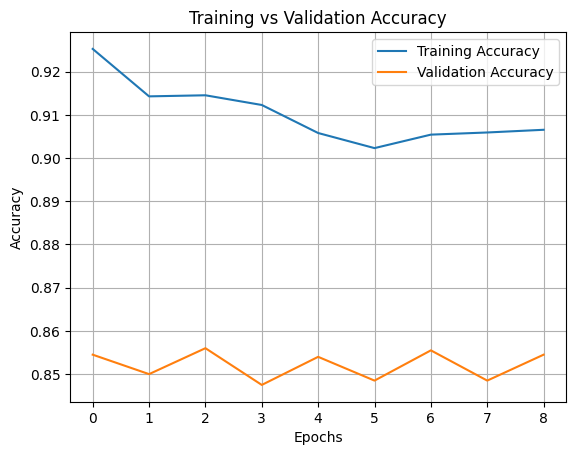

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.grid(True)

plt.show()